In [13]:
import pandas as pd
from prophet import Prophet
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [14]:
RAW = Path("../data/raw")
PROC = Path("../data/processed")
PROC.mkdir(parents=True, exist_ok=True)

In [15]:
orders = pd.read_csv(RAW / "orders.csv", parse_dates=["order_date"])


In [16]:
top_skus = (
    orders.groupby("sku_id")["qty_ordered"]
    .sum()
    .nlargest(10)
    .index
    .tolist()
)
print("Top 10 SKUs:", top_skus)

Top 10 SKUs: ['SKU0069', 'SKU0098', 'SKU0050', 'SKU0034', 'SKU0094', 'SKU0044', 'SKU0030', 'SKU0019', 'SKU0020', 'SKU0060']


In [17]:
forecast_results = []

13:17:32 - cmdstanpy - INFO - Chain [1] start processing
13:17:35 - cmdstanpy - INFO - Chain [1] done processing


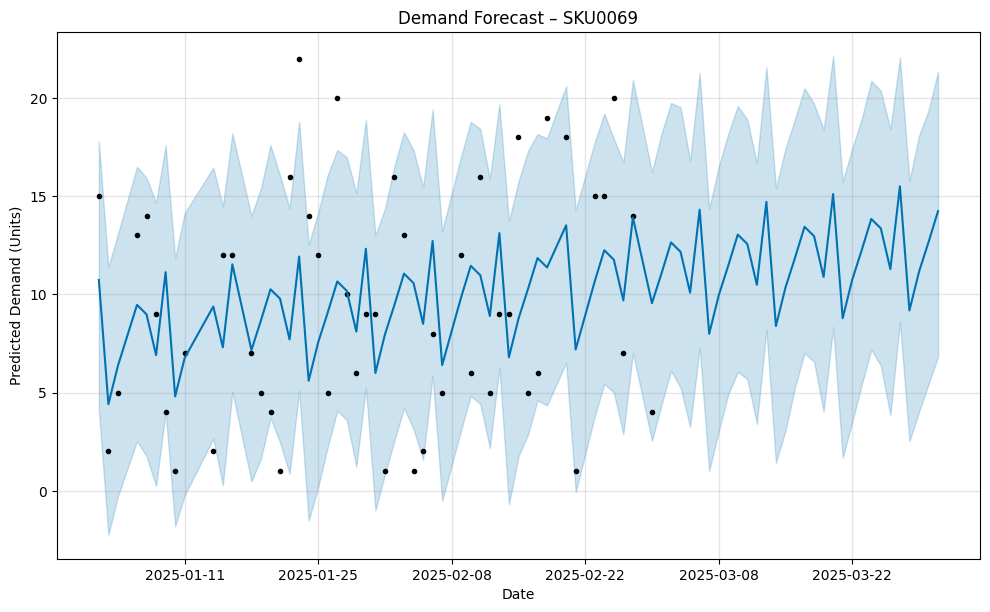

13:17:37 - cmdstanpy - INFO - Chain [1] start processing
13:17:38 - cmdstanpy - INFO - Chain [1] done processing


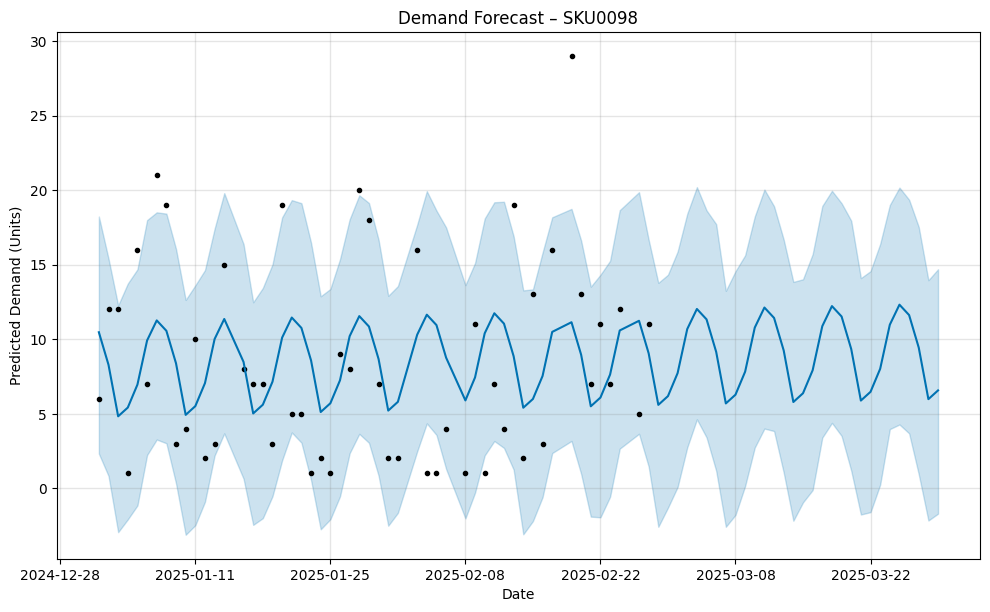

13:17:39 - cmdstanpy - INFO - Chain [1] start processing
13:17:40 - cmdstanpy - INFO - Chain [1] done processing


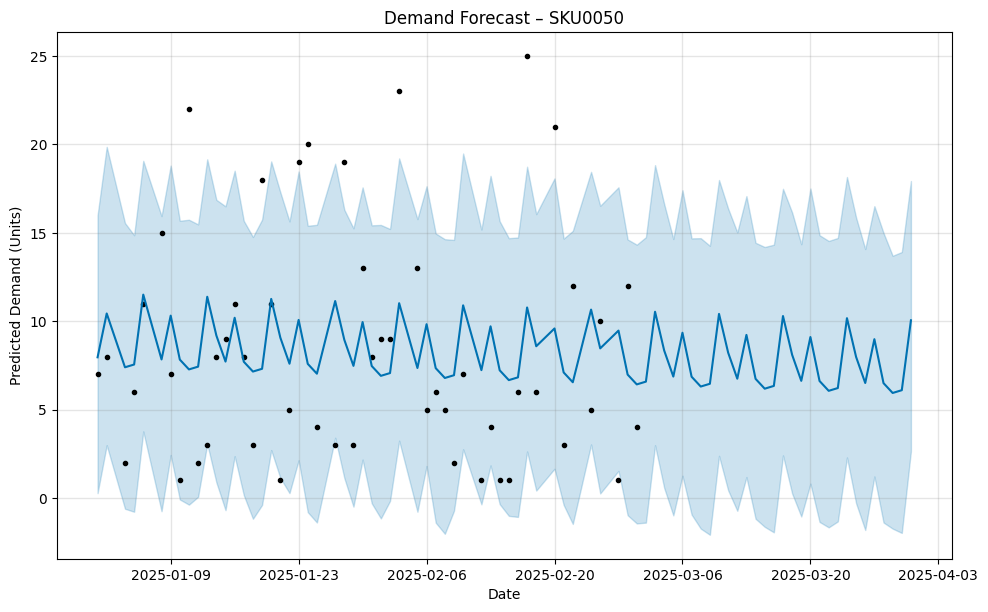

13:17:41 - cmdstanpy - INFO - Chain [1] start processing
13:17:41 - cmdstanpy - INFO - Chain [1] done processing


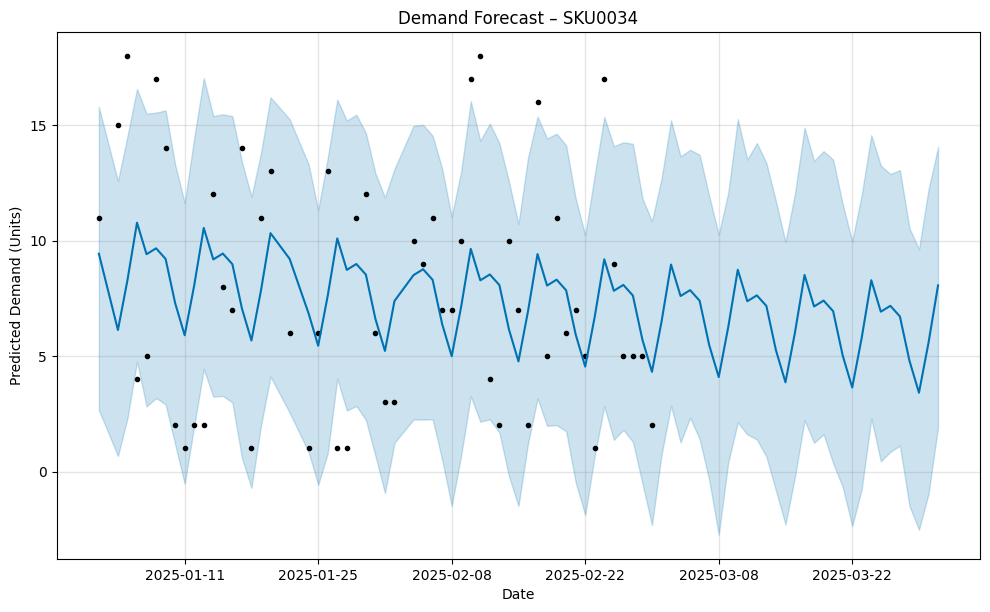

13:17:42 - cmdstanpy - INFO - Chain [1] start processing
13:17:42 - cmdstanpy - INFO - Chain [1] done processing


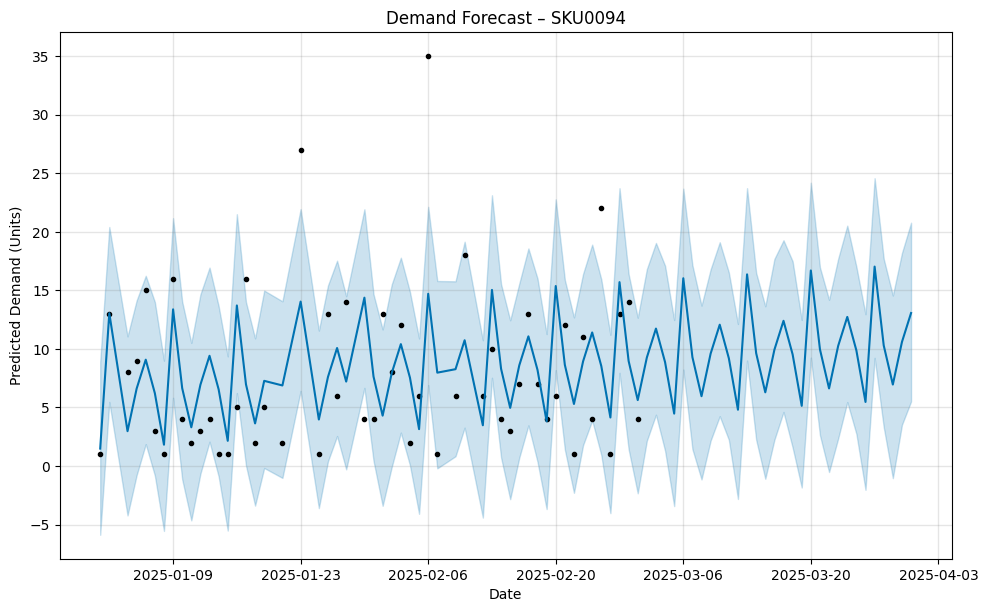

13:17:43 - cmdstanpy - INFO - Chain [1] start processing
13:17:44 - cmdstanpy - INFO - Chain [1] done processing


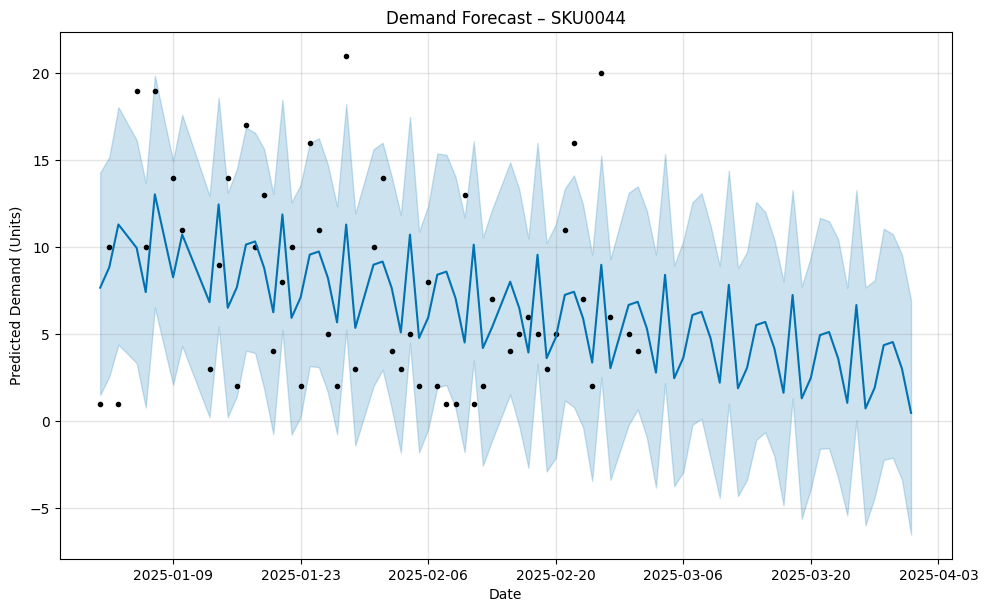

13:17:45 - cmdstanpy - INFO - Chain [1] start processing
13:17:46 - cmdstanpy - INFO - Chain [1] done processing


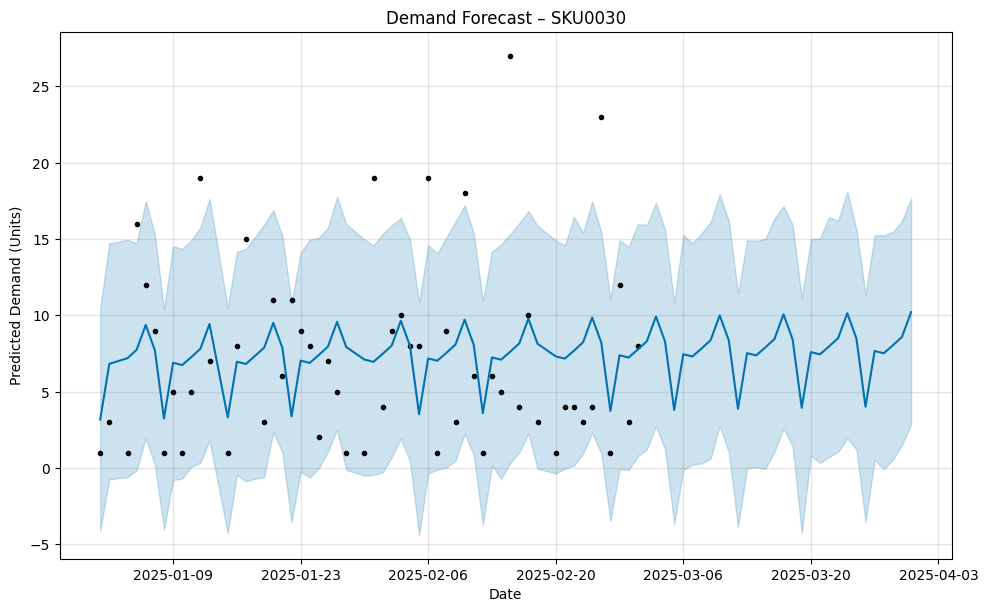

13:17:47 - cmdstanpy - INFO - Chain [1] start processing
13:17:47 - cmdstanpy - INFO - Chain [1] done processing


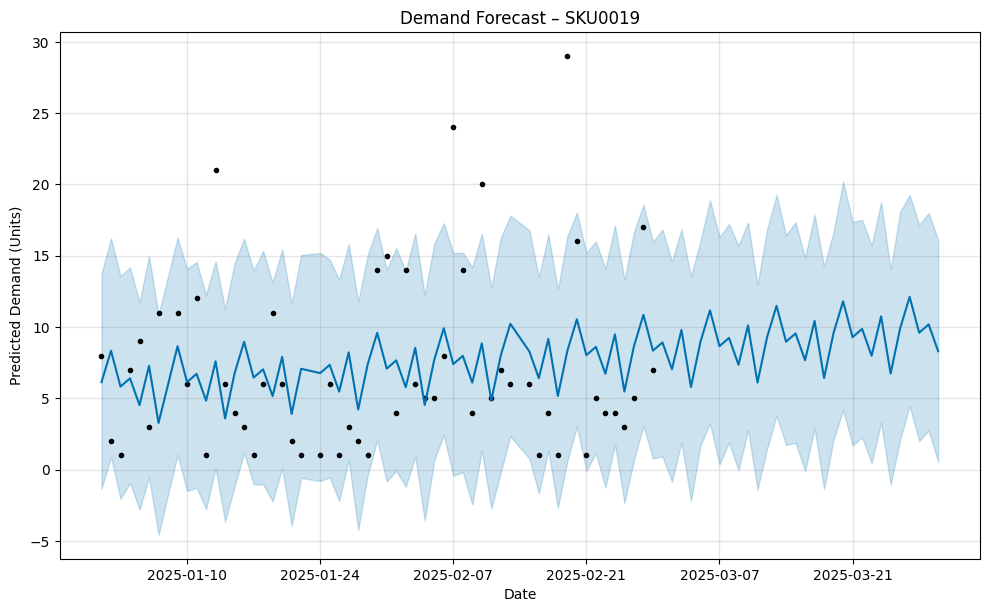

13:17:48 - cmdstanpy - INFO - Chain [1] start processing
13:17:49 - cmdstanpy - INFO - Chain [1] done processing


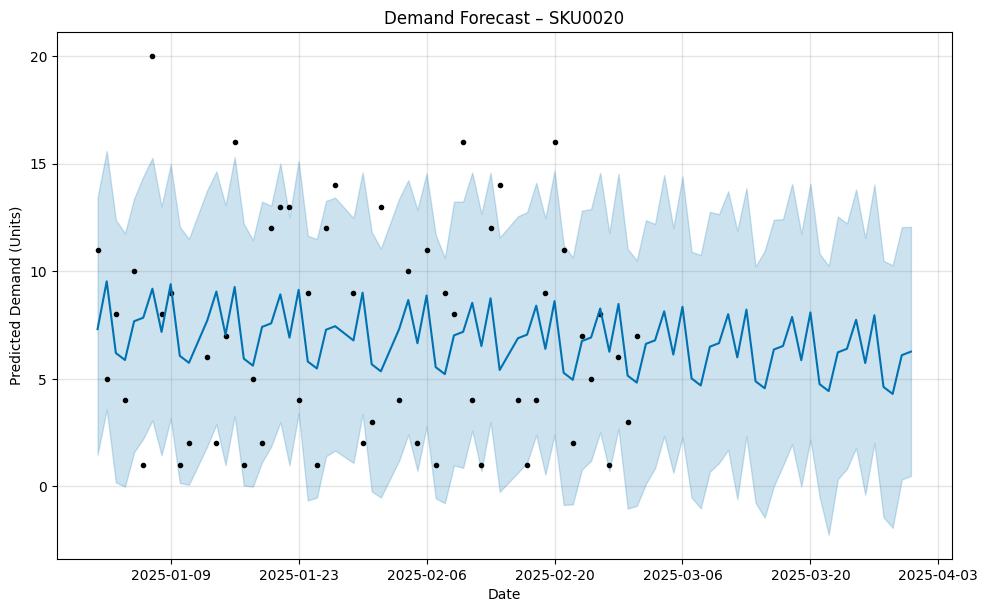

13:17:49 - cmdstanpy - INFO - Chain [1] start processing
13:17:50 - cmdstanpy - INFO - Chain [1] done processing


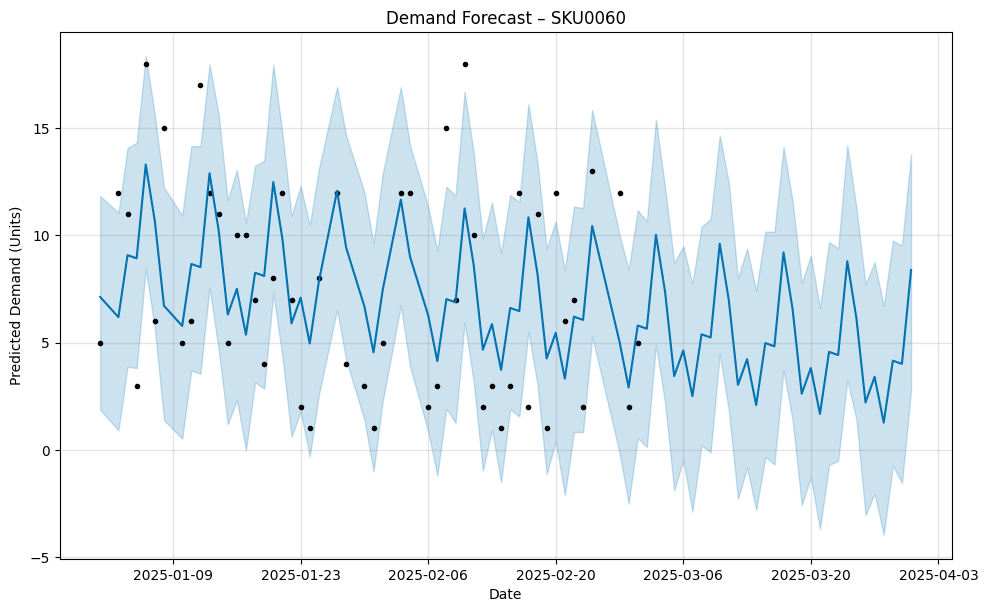

In [18]:
for sku in top_skus:
    df = (
        orders[orders["sku_id"] == sku]
        .groupby("order_date")
        .agg({"qty_ordered": "sum"})
        .reset_index()
        .rename(columns={"order_date": "ds", "qty_ordered": "y"})
    )

    # Skip SKUs with too few data points
    if len(df) < 10:
        continue

    # Prophet model
    model = Prophet(daily_seasonality=True)
    model.fit(df)

    # Forecast next 30 days
    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)
    forecast["sku_id"] = sku

    forecast[["ds", "yhat", "yhat_lower", "yhat_upper", "sku_id"]].to_csv(
        PROC / f"forecast_{sku}.csv", index=False
    )

    # Plot result
    fig = model.plot(forecast)
    plt.title(f"Demand Forecast – {sku}")
    plt.xlabel("Date")
    plt.ylabel("Predicted Demand (Units)")
    plt.show()


In [ ]:
import pandas as pd
from pathlib import Path

PROC = Path("../data/processed")

# Look for all individual forecast files
files = list(PROC.glob("forecast_SKU*.csv"))

if files:
    all_forecasts = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    all_forecasts.to_csv(PROC / "all_sku_forecasts.csv", index=False)
    print(f"✅ Combined {len(files)} forecast files into all_sku_forecasts.csv")
else:
    print("⚠️ No individual forecast files found in data/processed/")



✅ Combined 11 forecast files into all_sku_forecasts.csv


: 